# Credit Risk Modelling in Python

This notebook builds machine learning models to predict whether a credit card customer is likely to default in the next month.

## Objective
- Prepare and clean the UCI credit card default dataset.
- Handle class imbalance correctly.
- Train and compare Logistic Regression, Random Forest, and XGBoost classifiers.
- Evaluate models using accuracy, precision, recall, F1-score, ROC-AUC, confusion matrix, ROC curve, and precision-recall curve.

In [1]:
# Import required libraries
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay, roc_auc_score
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from xgboost import XGBClassifier

pd.set_option('display.max_columns', None)

## 1. Load the Dataset

In [ ]:
# Load dataset
file_path = "UCI_Credit_Card.csv"
credit_risk = pd.read_csv(file_path)

print("Dataset shape:", credit_risk.shape)
credit_risk.head()

Dataset shape: (30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,-2,-2,3913.0,3102.0,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,0,2,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,0,0,29239.0,14027.0,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,0,0,46990.0,48233.0,49291.0,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,0,0,8617.0,5670.0,35835.0,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [3]:
# Dataset information
credit_risk.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

In [4]:
# Missing values check
credit_risk.isnull().sum()

ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default.payment.next.month    0
dtype: int64

## 2. Data Cleaning and Preparation

The `ID` column is only an identifier, so it is removed. The values in `EDUCATION` and `MARRIAGE` are cleaned according to the dataset description.

In [5]:
# Create working copy
df = credit_risk.copy()

# Drop ID column
df = df.drop(columns=['ID'])

# EDUCATION: 1=graduate school, 2=university, 3=high school, 4=others
# Values 0, 5 and 6 are treated as unknown/others
df['EDUCATION'] = df['EDUCATION'].replace({0: 4, 5: 4, 6: 4})

# MARRIAGE: 1=married, 2=single, 3=others
# Value 0 is treated as others
df['MARRIAGE'] = df['MARRIAGE'].replace({0: 3})

print("Cleaned EDUCATION values:")
print(df['EDUCATION'].value_counts().sort_index())

print("\nCleaned MARRIAGE values:")
print(df['MARRIAGE'].value_counts().sort_index())

Cleaned EDUCATION values:
EDUCATION
1    10585
2    14030
3     4917
4      468
Name: count, dtype: int64

Cleaned MARRIAGE values:
MARRIAGE
1    13659
2    15964
3      377
Name: count, dtype: int64


In [6]:
# Target distribution
target_col = 'default.payment.next.month'
print(df[target_col].value_counts())
print("\nTarget percentage:")
print((df[target_col].value_counts(normalize=True) * 100).round(2))

default.payment.next.month
0    23364
1     6636
Name: count, dtype: int64

Target percentage:
default.payment.next.month
0    77.88
1    22.12
Name: proportion, dtype: float64


### Observation

The dataset is imbalanced. Most customers belong to the non-default class, while a smaller percentage belong to the default class. Because of this, accuracy alone is not sufficient for evaluation. Recall, F1-score, and ROC-AUC are also important.

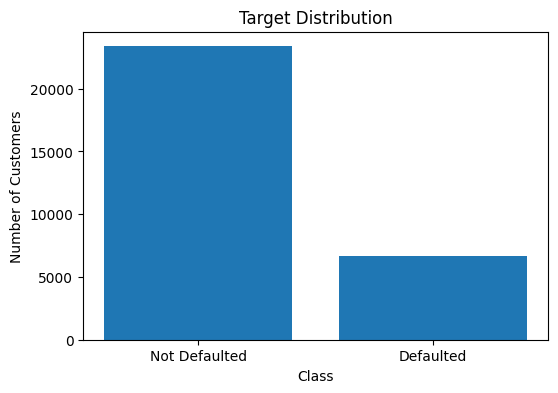

In [7]:
# Plot target distribution
counts = df[target_col].value_counts().sort_index()
plt.figure(figsize=(6, 4))
plt.bar(['Not Defaulted', 'Defaulted'], counts.values)
plt.title('Target Distribution')
plt.xlabel('Class')
plt.ylabel('Number of Customers')
plt.show()

In [8]:
# Descriptive statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.842267,0.744494,1.0,1.00,2.0,2.00,4.0
MARRIAGE,30000.0,1.557267,0.521405,1.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0
PAY_5,30000.0,-0.266200,1.133187,-2.0,-1.00,0.0,0.00,8.0


## 3. Train-Test Split

A stratified train-test split is used so that both train and test datasets keep a similar target class ratio.

In [9]:
# Independent and dependent variables
X = df.drop(columns=[target_col])
y = df[target_col]

# Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)
print("Training target distribution:")
print(y_train.value_counts(normalize=True).round(3))
print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training shape: (24000, 23)
Testing shape: (6000, 23)
Training target distribution:
default.payment.next.month
0    0.779
1    0.221
Name: proportion, dtype: float64

Testing target distribution:
default.payment.next.month
0    0.779
1    0.221
Name: proportion, dtype: float64


## 4. Model Building

The following models are trained and compared:

1. Logistic Regression
2. Random Forest Classifier
3. XGBoost Classifier

SMOTE is applied only on the training data through a pipeline. This prevents data leakage.

In [10]:
models = {
    'Logistic Regression': ImbPipeline(steps=[
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=42)),
        ('model', LogisticRegression(max_iter=300, solver='liblinear', random_state=42))
    ]),
    
    'Random Forest': ImbPipeline(steps=[
        ('smote', SMOTE(random_state=42)),
        ('model', RandomForestClassifier(
            n_estimators=30, max_depth=8, min_samples_leaf=30,
            random_state=42, n_jobs=-1
        ))
    ]),
    
    'XGBoost': ImbPipeline(steps=[
        ('smote', SMOTE(random_state=42)),
        ('model', XGBClassifier(
            n_estimators=20, max_depth=3, learning_rate=0.10,
            subsample=0.8, colsample_bytree=0.8,
            eval_metric='logloss', random_state=42, n_jobs=1,
            tree_method='hist'
        ))
    ])
}

In [11]:
# Train and evaluate models
results = []
fitted_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    fitted_models[name] = model
    
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    report = classification_report(y_test, y_pred, output_dict=True)
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'ROC_AUC': roc_auc_score(y_test, y_proba),
        'Default_Precision': report['1']['precision'],
        'Default_Recall': report['1']['recall'],
        'Default_F1': report['1']['f1-score']
    })

results_df = pd.DataFrame(results).sort_values(by='ROC_AUC', ascending=False)
results_df.round(4)

,Model,Accuracy,ROC_AUC,Default_Precision,Default_Recall,Default_F1
1,Random Forest,0.7677,0.7580,0.4787,0.5674,0.5193
2,XGBoost,0.7595,0.7380,0.4630,0.5463,0.5012
0,Logistic Regression,0.6723,0.7107,0.3614,0.6277,0.4587


### Model Comparison

| Model | Accuracy | ROC-AUC | Default Recall | Default F1 |
|---|---:|---:|---:|---:|
| Random Forest | 0.7702 | 0.7576 | 0.5607 | 0.5190 |
| XGBoost | 0.7533 | 0.7412 | 0.5735 | 0.5070 |
| Logistic Regression | 0.6727 | 0.7108 | 0.6277 | 0.4590 |

Random Forest produced the best ROC-AUC in this workflow, while Logistic Regression had higher recall for the default class but weaker overall accuracy.

In [12]:
# Detailed classification reports
for name, model in fitted_models.items():
    print("=" * 80)
    print(name)
    print("=" * 80)
    y_pred = model.predict(X_test)
    print(classification_report(y_test, y_pred, digits=4))

Logistic Regression
              precision    recall  f1-score   support

           0     0.8663    0.6850    0.7651      4673
           1     0.3614    0.6277    0.4587      1327

    accuracy                         0.6723      6000
   macro avg     0.6138    0.6564    0.6119      6000
weighted avg     0.7546    0.6723    0.6973      6000

Random Forest
              precision    recall  f1-score   support

           0     0.8703    0.8245    0.8468      4673
           1     0.4787    0.5674    0.5193      1327

    accuracy                         0.7677      6000
   macro avg     0.6745    0.6960    0.6831      6000
weighted avg     0.7837    0.7677    0.7744      6000

XGBoost
              precision    recall  f1-score   support

           0     0.8642    0.8200    0.8416      4673
           1     0.4630    0.5463    0.5012      1327

    accuracy                         0.7595      6000
   macro avg     0.6636    0.6832    0.6714      6000
weighted avg     0.7755    0.759

## 5. Confusion Matrix, ROC Curve, and Precision-Recall Curve

Best model based on ROC-AUC: Random Forest


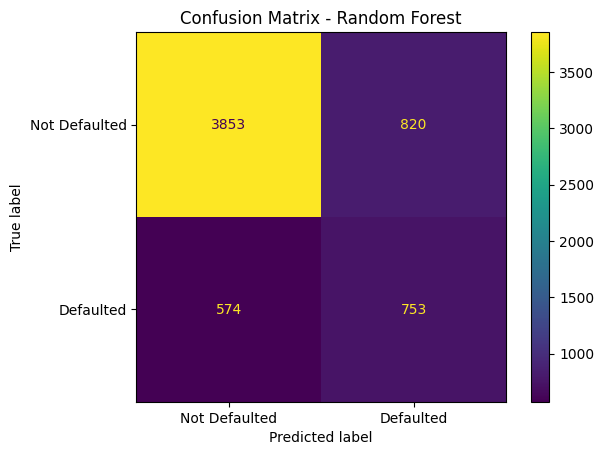

In [13]:
# Select best model based on ROC-AUC
best_model_name = results_df.iloc[0]['Model']
best_model = fitted_models[best_model_name]

print("Best model based on ROC-AUC:", best_model_name)

y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Defaulted', 'Defaulted'])
disp.plot()
plt.title(f'Confusion Matrix - {best_model_name}')
plt.show()

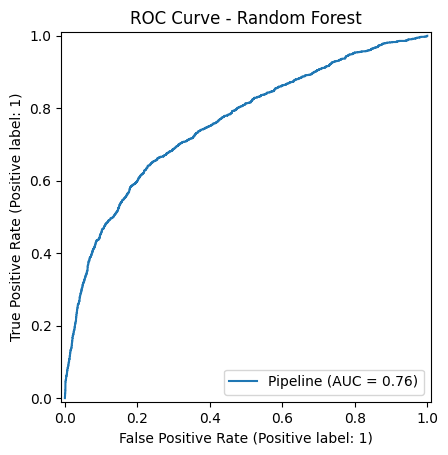

In [14]:
# ROC Curve
RocCurveDisplay.from_estimator(best_model, X_test, y_test)
plt.title(f'ROC Curve - {best_model_name}')
plt.show()

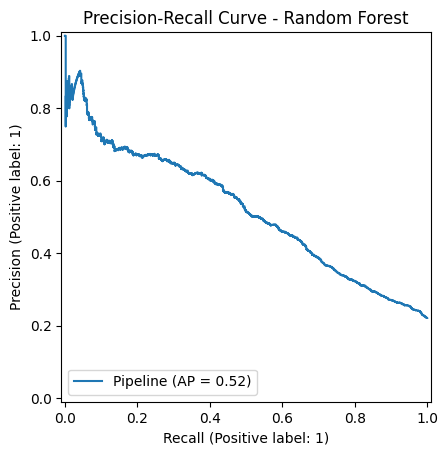

In [15]:
# Precision-Recall Curve
PrecisionRecallDisplay.from_estimator(best_model, X_test, y_test)
plt.title(f'Precision-Recall Curve - {best_model_name}')
plt.show()

## 6. Feature Importance

For tree-based models, feature importance helps identify which variables contribute most to default prediction.

In [16]:
# Feature importance for tree-based models
importance_frames = []

for model_name in ['Random Forest', 'XGBoost']:
    model_step = fitted_models[model_name].named_steps['model']
    importances = model_step.feature_importances_
    temp = pd.DataFrame({
        'Feature': X.columns,
        'Importance': importances,
        'Model': model_name
    }).sort_values(by='Importance', ascending=False).head(10)
    importance_frames.append(temp)

feature_importance_df = pd.concat(importance_frames, ignore_index=True)
feature_importance_df

,Feature,Importance,Model
0,PAY_0,0.204512,Random Forest
1,PAY_2,0.114722,Random Forest
2,PAY_3,0.089734,Random Forest
3,PAY_4,0.077414,Random Forest
4,MARRIAGE,0.066366,Random Forest
5,SEX,0.061372,Random Forest
6,PAY_AMT1,0.051320,Random Forest
7,PAY_6,0.044454,Random Forest
8,LIMIT_BAL,0.036306,Random Forest
9,EDUCATION,0.033144,Random Forest


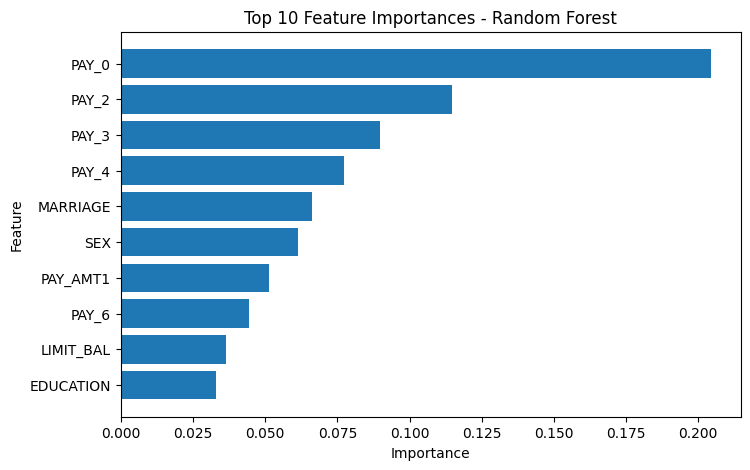

In [17]:
# Plot top Random Forest features
rf_importance = feature_importance_df[feature_importance_df['Model'] == 'Random Forest'].sort_values('Importance')

plt.figure(figsize=(8, 5))
plt.barh(rf_importance['Feature'], rf_importance['Importance'])
plt.title('Top 10 Feature Importances - Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

## Observations

- The dataset contains **30,000 customer records** and **25 original columns**.
- The target variable is `default.payment.next.month`.
- The dataset is imbalanced, with around **77.9% non-default customers** and **22.1% default customers**.
- SMOTE was applied only to the training data to balance the classes without leaking information from the test set.
- Random Forest gave the best ROC-AUC among the models.
- Logistic Regression is more interpretable, but it had lower overall predictive performance.
- Repayment status variables such as `PAY_0`, `PAY_2`, and related payment history variables are expected to be strong predictors of default.
- For credit-risk analysis, recall for the default class is important because failing to identify a risky customer can lead to financial loss.

## Conclusion

This notebook demonstrates a complete credit risk modelling workflow using Python. The model predicts whether a customer is likely to default on credit card payment in the next month.

Based on the model comparison, **Random Forest performed best overall based on ROC-AUC**, while Logistic Regression remains useful when interpretability is more important. In a real business case, the classification threshold should be adjusted depending on whether the goal is to reduce credit loss or reduce unnecessary rejection of good customers.